# 05 · Combine & compare

Reads the nine CSVs written by notebooks 01–04. Run those first.

Replaces the old `KR_comparison` + `KR_stats` pair. Two things changed:

* the old `KR_comparison` cell recomputed `cross_cutting` as a *share* of
  minority exposure, while the per-cell notebooks used *distance*. Only the
  distance definition survives here.
* `producer_type` is no longer reassigned anywhere — it comes from the files.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = "D:/School/2026 Spring/KR_Polarization/dataset"

CELLS = [
    ("politicians/youtube",   "Politician", "YouTube"),
    ("politicians/instagram", "Politician", "Instagram"),
    ("influencers/youtube",     "YouTuber",   "YouTube"),
    ("influencers/instagram",   "YouTuber",   "Instagram"),
]
import statsmodels.formula.api as smf

## 1. Load and verify labels

In [3]:
def load(kind):
    frames = []
    for sub, ptype, plat in CELLS:
        path = f"{ROOT}/{sub}/{kind}.csv"
        try:
            d = pd.read_csv(path)
        except FileNotFoundError:
            print(f"  MISSING {path}")
            continue

        bad_pt = set(d["producer_type"]) != {ptype}
        bad_pl = set(d["platform"]) != {plat}
        if bad_pt or bad_pl:
            raise ValueError(
                f"{path} is mislabelled: {set(d['producer_type'])} / "
                f"{set(d['platform'])} — expected {ptype} / {plat}. "
                "Re-run the notebook that writes it."
            )

        frames.append(d)

    return pd.concat(frames, ignore_index=True)


all_users    = load("user_counts")
all_channels = load("channel_df")
all_videos   = load("video_df")

print("users   :", all_users.shape)
print("channels:", all_channels.shape)
print("videos  :", all_videos.shape)

users   : (78652, 10)
channels: (577, 14)
videos  : (75433, 16)


In [4]:
all_users.groupby(["producer_type", "platform"]).agg(
    n_users=("author", "nunique"),
    mean_bias=("user_bias", "mean"),
    mean_cross_cut=("user_cross_cut", "mean"),
)

n_users  mean_bias  mean_cross_cut
producer_type platform                                     
Politician    Instagram      980  -0.518091        0.080636
              YouTube       5282  -0.324715        0.073879
YouTuber      Instagram     4550  -0.000284        0.206674
              YouTube      67839   0.422868        0.083212

In [38]:
all_users["user_cross_cut"].describe()
(all_users["user_bias"].abs() > .99).mean()

0.6964095000762854

In [6]:
import numpy as np
print(np.abs(all_users["user_cross_cut"] - (1 - all_users["user_bias"]**2)).max())

3.885780586188048e-16


## 2. Producer composition

`user_bias` is driven partly by which producers are in each cell. If one cell
is 65% left-leaning producers and another is 38%, a user who comments at
random scores differently in each — so a raw group difference in `mean_bias`
is not purely a difference between users.

In [7]:
comp = (
    all_channels
    .groupby(["producer_type", "platform", "ideology"])
    .size()
    .unstack(fill_value=0)
)

comp["left_share"] = comp["left"] / (comp["left"] + comp["right"])
comp

ideology                 left  right  left_share
producer_type platform                          
Politician    Instagram    55     23    0.705128
              YouTube     177     82    0.683398
YouTuber      Instagram    26     42    0.382353
              YouTube      70    102    0.406977

## 3. Distributions

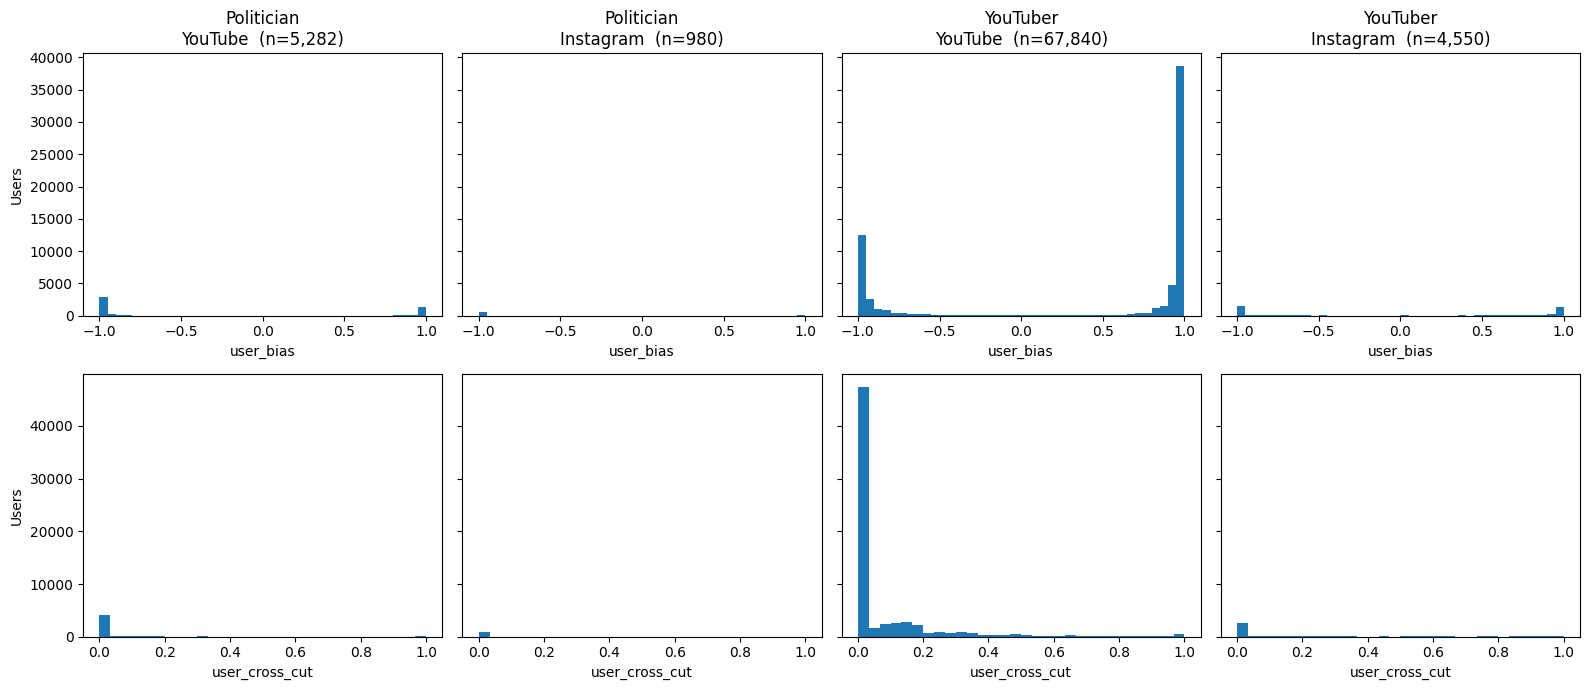

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey="row")

for j, (sub, ptype, plat) in enumerate(CELLS):
    d = all_users[(all_users["producer_type"] == ptype) &
                  (all_users["platform"] == plat)]

    axes[0, j].hist(d["user_bias"], bins=40)
    axes[0, j].set_title(f"{ptype}\n{plat}  (n={len(d):,})")
    axes[0, j].set_xlabel("user_bias")

    axes[1, j].hist(d["user_cross_cut"].dropna(), bins=30)
    axes[1, j].set_xlabel("user_cross_cut")

axes[0, 0].set_ylabel("Users")
axes[1, 0].set_ylabel("Users")
plt.tight_layout()
plt.show()

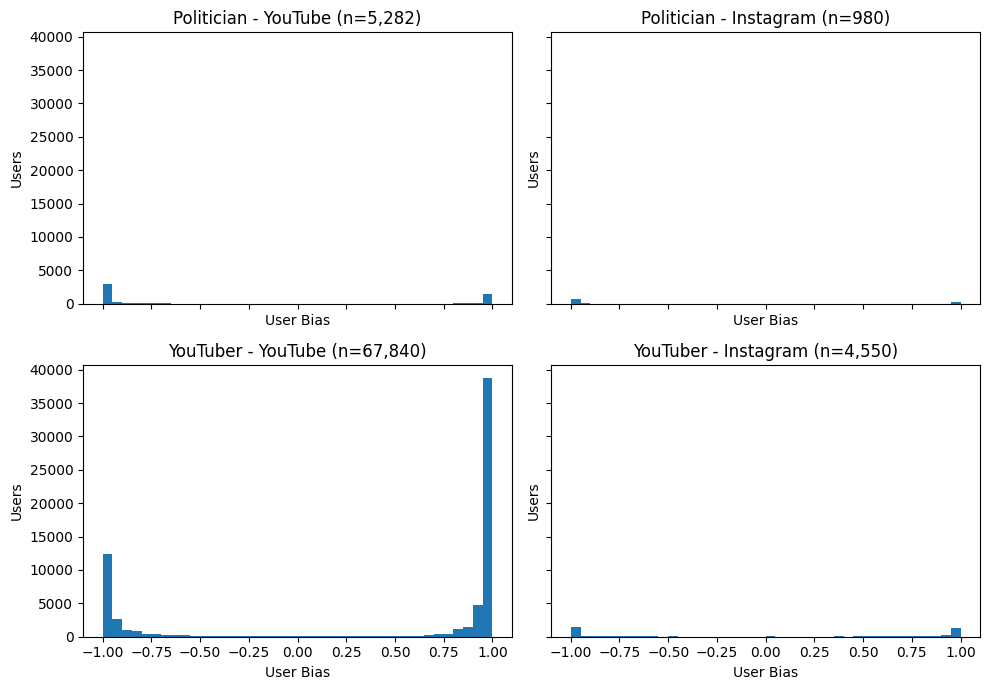

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
axes = axes.flatten()

for j, (sub, ptype, plat) in enumerate(CELLS):
    d = all_users[
        (all_users["producer_type"] == ptype) &
        (all_users["platform"] == plat)
    ]

    axes[j].hist(d["user_bias"].dropna(), bins=40)
    axes[j].set_title(f"{ptype} - {plat} (n={len(d):,})")
    axes[j].set_xlabel("User Bias")
    axes[j].set_ylabel("Users")

plt.tight_layout()
plt.show()

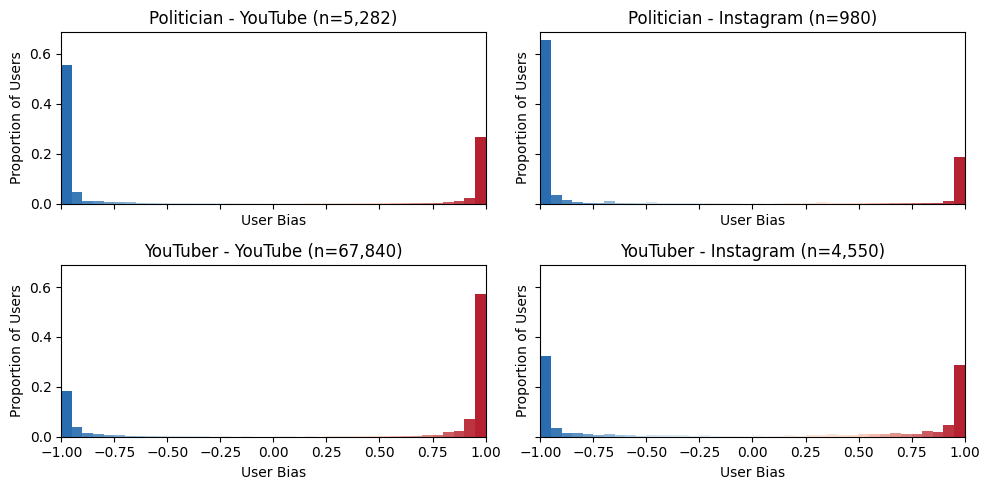

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

# Left = blue, center = very light, right = red
cmap = LinearSegmentedColormap.from_list(
    "ideology",
    ["#2166AC", "#D1E5F0", "#F7F7F7", "#FDDBC7", "#B2182B"]
)

norm = Normalize(vmin=-1, vmax=1)

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 5),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for j, (sub, ptype, plat) in enumerate(CELLS):

    d = all_users[
        (all_users["producer_type"] == ptype) &
        (all_users["platform"] == plat)
    ].copy()

    bias = d["user_bias"].dropna()

    # Proportion rather than raw counts
    weights = np.ones(len(bias)) / len(bias)

    counts, bins, patches = axes[j].hist(
        bias,
        bins=40,
        range=(-1, 1),
        weights=weights
    )

    # Color each histogram bin according to its position
    for left_edge, right_edge, patch in zip(
        bins[:-1], bins[1:], patches
    ):
        midpoint = (left_edge + right_edge) / 2
        patch.set_facecolor(cmap(norm(midpoint)))

    axes[j].set_title(
        f"{ptype} - {plat} (n={len(bias):,})"
    )

    axes[j].set_xlabel("User Bias")
    axes[j].set_ylabel("Proportion of Users")
    axes[j].set_xlim(-1, 1)

plt.tight_layout()
plt.show()

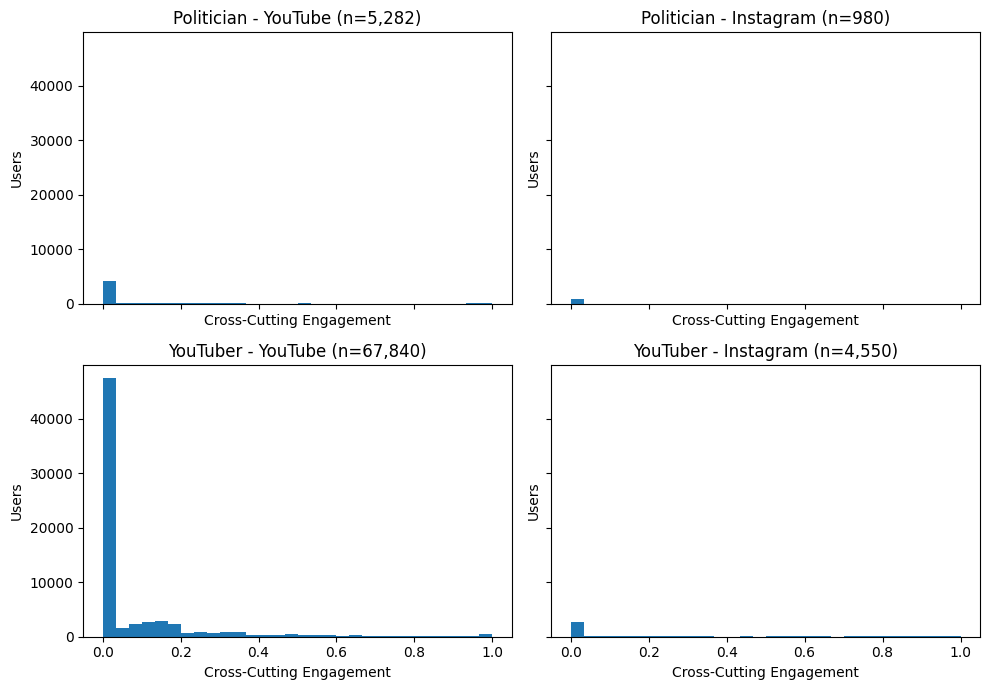

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
axes = axes.flatten()

for j, (sub, ptype, plat) in enumerate(CELLS):
    d = all_users[
        (all_users["producer_type"] == ptype) &
        (all_users["platform"] == plat)
    ]

    axes[j].hist(d["user_cross_cut"].dropna(), bins=30)
    axes[j].set_title(f"{ptype} - {plat} (n={len(d):,})")
    axes[j].set_xlabel("Cross-Cutting Engagement")
    axes[j].set_ylabel("Users")

plt.tight_layout()
plt.show()

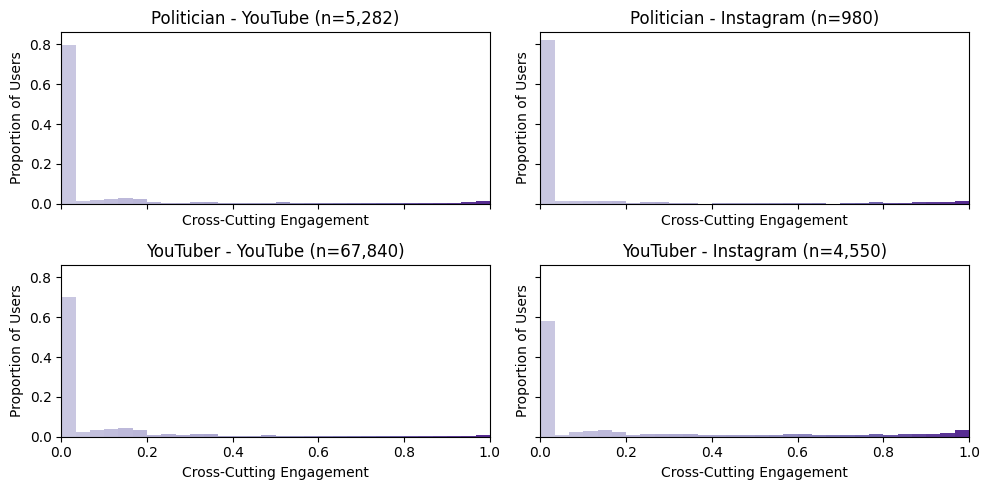

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

# Low cross-cutting = light purple
# High cross-cutting = dark purple
cmap_cross = LinearSegmentedColormap.from_list(
    "cross_cutting",
    ["#CBC9E2", "#B3AED4", "#9E9AC8", "#756BB1", "#54278F"]
)

norm_cross = Normalize(vmin=0, vmax=1)

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 5),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for j, (sub, ptype, plat) in enumerate(CELLS):

    d = all_users[
        (all_users["producer_type"] == ptype) &
        (all_users["platform"] == plat)
    ].copy()

    cross = d["user_cross_cut"].dropna()

    # Convert raw counts to proportion of users
    weights = np.ones(len(cross)) / len(cross)

    # Create histogram
    counts, bins, patches = axes[j].hist(
        cross,
        bins=30,
        range=(0, 1),
        weights=weights
    )

    # Color each bin according to cross-cutting value
    for left_edge, right_edge, patch in zip(
        bins[:-1], bins[1:], patches
    ):
        midpoint = (left_edge + right_edge) / 2
        patch.set_facecolor(
            cmap_cross(norm_cross(midpoint))
        )

    # Titles and labels
    axes[j].set_title(
        f"{ptype} - {plat} (n={len(cross):,})"
    )

    axes[j].set_xlabel("Cross-Cutting Engagement")
    axes[j].set_ylabel("Proportion of Users")

    # Cross-cutting score ranges from 0 to 1
    axes[j].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 4. Group tests

In [9]:
from scipy.stats import ks_2samp, mannwhitneyu

for plat in ["YouTube", "Instagram"]:
    sub = all_users[all_users["platform"] == plat]
    a = sub.loc[sub["producer_type"] == "Politician", "user_cross_cut"].dropna()
    b = sub.loc[sub["producer_type"] == "YouTuber",   "user_cross_cut"].dropna()

    if len(a) == 0 or len(b) == 0:
        print(f"{plat}: missing a group")
        continue

    u, p_u = mannwhitneyu(a, b, alternative="two-sided")
    k, p_k = ks_2samp(a, b)

    print(f"{plat}: politician mean={a.mean():.3f} (n={len(a):,}) | "
          f"youtuber mean={b.mean():.3f} (n={len(b):,})")
    print(f"   Mann-Whitney U={u:,.0f} p={p_u:.3g} | KS D={k:.3f} p={p_k:.3g}")

YouTube: politician mean=0.074 (n=5,282) | youtuber mean=0.083 (n=67,840)
   Mann-Whitney U=163,267,362 p=2.72e-40 | KS D=0.099 p=1.5e-42
Instagram: politician mean=0.081 (n=980) | youtuber mean=0.207 (n=4,550)
   Mann-Whitney U=1,673,158 p=6.85e-45 | KS D=0.246 p=1.85e-43


## 5. Activity bands

In [10]:
band = (
    all_users
    .dropna(subset=["user_cross_cut"])
    .groupby(["producer_type", "platform", "activity_band"], observed=True)["user_cross_cut"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

band["se"] = band["std"] / np.sqrt(band["count"])
band["ci95"] = 1.96 * band["se"]
band

,producer_type,platform,activity_band,mean,std,count,se,ci95
0,Politician,Instagram,100–299,0.109618,0.274064,64,0.034258,0.067146
1,Politician,Instagram,20–49,0.086793,0.230495,723,0.008572,0.016801
2,Politician,Instagram,300+,0.000000,0.000000,10,0.000000,0.000000
3,Politician,Instagram,50–99,0.050585,0.163123,183,0.012058,0.023634
4,Politician,YouTube,100–299,0.044253,0.153928,237,0.009999,0.019597
5,Politician,YouTube,20–49,0.080316,0.207501,4229,0.003191,0.006254
6,Politician,YouTube,300+,0.061142,0.192551,34,0.033022,0.064724
7,Politician,YouTube,50–99,0.048601,0.148625,782,0.005315,0.010417
8,YouTuber,Instagram,100–299,0.195563,0.307381,229,0.020312,0.039812
9,YouTuber,Instagram,20–49,0.207903,0.319529,3528,0.005380,0.010544


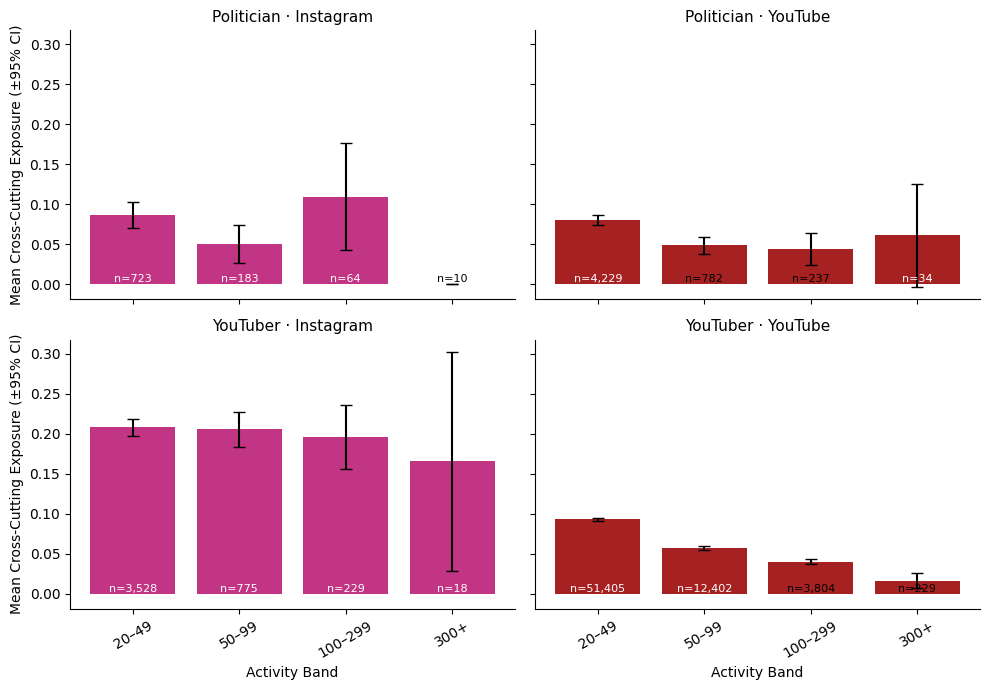

In [ ]:
import matplotlib.pyplot as plt

BAND_LABELS = ["20–49", "50–99", "100–299", "300+"]

producers = ["Politician", "YouTuber"]
platforms = ["Instagram", "YouTube"]

platform_colors = {
    "Instagram": "#C13584",
    "YouTube": "#A62121"
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 7),
    sharey=True,
    sharex=True
)

for i, prod in enumerate(producers):
    for j, plat in enumerate(platforms):
        ax = axes[i, j]

        s = (
            band[
                (band["producer_type"] == prod) &
                (band["platform"] == plat)
            ]
            .set_index("activity_band")
            .reindex(BAND_LABELS)
        )

        ax.bar(
            BAND_LABELS,
            s["mean"],
            yerr=s["ci95"],
            capsize=4,
            color=platform_colors[plat],
            edgecolor="none"
        )

        for x, (m, n) in enumerate(zip(s["mean"], s["count"])):
            if pd.notna(m):
                ax.text(
                    x,
                    0,
                    f"n={int(n):,}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    color="white" if m > 0.05 else "black"
                )

        ax.set_title(f"{prod} · {plat}", fontsize=11)
        ax.spines[["top", "right"]].set_visible(False)

for ax in axes[1, :]:
    ax.set_xlabel("Activity Band")
    ax.tick_params(axis="x", rotation=30)

for ax in axes[:, 0]:
    ax.set_ylabel("Mean Cross-Cutting Engagement (±95% CI)")

fig.tight_layout()
plt.show()

In [36]:
m_activity = smf.ols(
    """
    user_cross_cut ~
    np.log1p(total) * C(producer_type) * C(platform) +
    np.log1p(n_producers)
    """,
    data=usr
).fit(cov_type="HC2")

print(m_activity.summary())

                            OLS Regression Results                            
Dep. Variable:         user_cross_cut   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     443.3
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:59:59   Log-Likelihood:                 18270.
No. Observations:               78652   AIC:                        -3.652e+04
Df Residuals:                   78643   BIC:                        -3.644e+04
Df Model:                           8                                         
Covariance Type:                  HC2                                         
                                                                          coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------

### User level

Two specifications. The first mirrors the original `KR_comparison` model so
the numbers stay comparable; the second is the one to report.

`user_cross_cut` is defined as mean |channel_bias - user_bias|, so `user_bias`
sits on both sides of the first equation — the correlation check below shows
how tightly. Its coefficient there is not interpretable as an effect. The
second model drops it, adds the platform axis the 2x2 design needs, and uses
HC2 standard errors (the residuals are heavily skewed, so the default
`nonrobust` errors understate uncertainty).

In [12]:
usr = all_users.dropna(subset=["user_cross_cut", "user_bias", "total"]).copy()

print("n =", f"{len(usr):,}")
print(usr[["user_cross_cut", "user_bias", "total"]].corr().to_string())

usr["user_bias_sq"] = usr["user_bias"] ** 2
print()
print("corr(user_cross_cut, user_bias_sq) =",
      round(usr["user_cross_cut"].corr(usr["user_bias_sq"]), 3))

n = 78,652
                user_cross_cut  user_bias     total
user_cross_cut        1.000000   -0.13641 -0.051791
user_bias            -0.136410    1.00000  0.006240
total                -0.051791    0.00624  1.000000

corr(user_cross_cut, user_bias_sq) = -1.0


In [19]:
# Reported specification: no user_bias, both design axes, HC2
m_user = smf.ols(
    """
    user_cross_cut ~
    user_bias +
    C(producer_type) * C(platform) +
    np.log1p(total) +
    np.log1p(n_producers)
    """,
    data=usr,
).fit(cov_type="HC2")

print(m_user.summary())

                            OLS Regression Results                            
Dep. Variable:         user_cross_cut   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     1043.
Date:                Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:49:03   Log-Likelihood:                 20478.
No. Observations:               78652   AIC:                        -4.094e+04
Df Residuals:                   78645   BIC:                        -4.088e+04
Df Model:                           6                                         
Covariance Type:                  HC2                                         
                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------

## 6. Regressions

Producer level uses HC2. Item level clusters on `channel_id`, because several
items share a producer and their residuals are not independent.

`subscriber_count` / follower count is not merged in yet — add it as a
control once the Instagram follower scrape is done.

In [21]:
ch = all_channels[all_channels["ideology"].isin(["left", "right"])].copy()

# audience_size is only a usable control where it was actually collected
has_size = ch["audience_size"].notna().mean()
print(f"audience_size available for {has_size:.0%} of producers")

formula = """
    mean_cross_cutting ~
    mean_user_bias +
    C(producer_type) * C(platform) +
    C(ideology) +
    np.log1p(total_likes) +
    np.log1p(n_users) +
    np.log1p(n_comments)
"""

if has_size > 0.8:
    formula += "+ np.log1p(audience_size)"
    ch = ch.dropna(subset=["audience_size"])
else:
    print("  -> dropping audience_size from the model (too many missing)")

m_channel = smf.ols(formula, data=ch).fit(cov_type="HC2")

print(m_channel.summary())

audience_size available for 96% of producers
                            OLS Regression Results                            
Dep. Variable:     mean_cross_cutting   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                     60.69
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           2.43e-76
Time:                        15:49:37   Log-Likelihood:                 260.26
No. Observations:                 552   AIC:                            -500.5
Df Residuals:                     542   BIC:                            -457.4
Df Model:                           9                                         
Covariance Type:                  HC2                                         
                                                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------

In [22]:
vid = all_videos[all_videos["ideology"].isin(["left", "right"])].dropna(
    subset=["mean_cross_cutting", "total_likes",
            "n_users", "n_comments", "channel_id"]
).copy()

vid["cluster"] = (
    vid["producer_type"].astype(str) + "|" +
    vid["platform"].astype(str) + "|" +
    vid["channel_id"].astype(str)
)

formula_v = """
    mean_cross_cutting ~
    mean_user_bias +
    C(producer_type) * C(platform) +
    C(ideology) +
    np.log1p(total_likes) +
    np.log1p(n_users) +
    np.log1p(n_comments)
"""

if vid["audience_size"].notna().mean() > 0.8:
    formula_v += "+ np.log1p(audience_size)"
    vid = vid.dropna(subset=["audience_size"])

print(f"items: {len(vid):,} | clusters: {vid['cluster'].nunique():,}")

m_video = smf.ols(formula_v, data=vid).fit(
    cov_type="cluster", cov_kwds={"groups": vid["cluster"]}
)

print(m_video.summary())

items: 70,992 | clusters: 552
                            OLS Regression Results                            
Dep. Variable:     mean_cross_cutting   R-squared:                       0.031
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     3.806
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           0.000112
Time:                        15:50:14   Log-Likelihood:                 7586.4
No. Observations:               70992   AIC:                        -1.515e+04
Df Residuals:                   70982   BIC:                        -1.506e+04
Df Model:                           9                                         
Covariance Type:              cluster                                         
                                                          coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------

## 8. Save combined

In [18]:
all_users.to_csv(f"{ROOT}/all_user_counts.csv", index=False, encoding="utf-8-sig")
all_channels.to_csv(f"{ROOT}/all_channel_df.csv", index=False, encoding="utf-8-sig")
all_videos.to_csv(f"{ROOT}/all_video_df.csv", index=False, encoding="utf-8-sig")

print("saved")

saved
